<a href="https://colab.research.google.com/github/SGHPK0905/PPNCKH_5Bros/blob/Phuong/Phuong_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Thiết lập môi trường và cấu trúc thư mục GitHub trên Colab
Khởi tạo đường dẫn dự án Project/data/raw/beijing/ để đồng bộ với cấu trúc của nhánh GitHub. Nạp tệp dữ liệu thô và chuyển đổi cột thời gian thành DatetimeIndex.

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings('ignore')

# Tái tạo cấu trúc thư mục GitHub ngay trên Colab
os.makedirs("Project/data/raw/beijing/", exist_ok=True)

# đoạn code này sẽ tự copy file đó vào đúng thư mục Project để chạy.
if os.path.exists("PRSA_data_2010.1.1-2014.12.31.csv"):
    import shutil
    shutil.copy("PRSA_data_2010.1.1-2014.12.31.csv", "Project/data/raw/beijing/PRSA_data_2010.1.1-2014.12.31.csv")

file_path = "Project/data/raw/beijing/PRSA_data_2010.1.1-2014.12.31.csv"

# Đọc dữ liệu
df = pd.read_csv(file_path)
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.set_index('datetime', inplace=True)
df.drop(columns=['No', 'year', 'month', 'day', 'hour'], inplace=True, errors='ignore')
print(f"Đã nạp dữ liệu thành công. Kích thước: {df.shape}")

Đã nạp dữ liệu thành công. Kích thước: (43824, 8)


#2. Data Audit (Kiểm toán Dữ liệu Thô)
Thực hiện quét toàn diện dữ liệu: số dòng, trùng lặp, phần trăm missing, tháng bị thiếu nhiều nhất và khoảng trống liên tiếp lớn nhất. Tạo cờ đánh dấu chất lượng (quality flags) và xuất báo cáo beijing_data_quality_report.csv.

In [7]:
audit_data = []
audit_data.append({'Metric': 'Tổng số dòng (Hours)', 'Value': len(df)})
audit_data.append({'Metric': 'Số dòng trùng lặp (Duplicates)', 'Value': df.duplicated().sum()})
audit_data.append({'Metric': 'Tỷ lệ thiếu PM2.5 (%)', 'Value': f"{(df['pm2.5'].isnull().sum() / len(df)) * 100:.2f}%"})

# Missing theo Năm-Tháng
missing_by_ym = df['pm2.5'].isnull().groupby([df.index.year, df.index.month]).sum()
max_missing_month = missing_by_ym.idxmax()
audit_data.append({'Metric': f'Tháng thiếu PM2.5 nhiều nhất', 'Value': f"Năm {max_missing_month[0]}, Tháng {max_missing_month[1]} ({missing_by_ym.max()} giờ)"})

# Tính khoảng trống liên tiếp dài nhất (Consecutive Gaps)
gaps = df['pm2.5'].isnull().astype(int).groupby(df['pm2.5'].notnull().astype(int).cumsum()).sum()
audit_data.append({'Metric': 'Khoảng trống liên tiếp lớn nhất (Giờ)', 'Value': gaps.max()})

# Tạo Quality Flag
df['pm2.5_missing_flag'] = df['pm2.5'].isnull().astype(int)

df_audit = pd.DataFrame(audit_data)
df_audit.to_csv("beijing_data_quality_report.csv", index=False)
display(df_audit)

,Metric,Value
0,Tổng số dòng (Hours),43824
1,Số dòng trùng lặp (Duplicates),14
2,Tỷ lệ thiếu PM2.5 (%),4.72%
3,Tháng thiếu PM2.5 nhiều nhất,"Năm 2010, Tháng 9 (252 giờ)"
4,Khoảng trống liên tiếp lớn nhất (Giờ),155


#3. Làm sạch Dữ liệu
Sử dụng nội suy tuyến tính một chiều (forward fill) với giới hạn 24 giờ. Tuyệt đối không dùng nội suy hai phía (both) để tránh việc mô hình học máy lấy thông tin của tương lai điền cho quá khứ. Mã hóa One-Hot biến hướng gió.

In [8]:
# CHỐNG LEAKAGE: Chỉ dùng dữ liệu quá khứ điền cho tương lai (limit_direction='forward')
df['pm2.5_clean'] = df['pm2.5'].interpolate(method='linear', limit_direction='forward', limit=24)

# One-hot encoding biến Gió
df = pd.get_dummies(df, columns=['cbwd'], prefix='wind')
for col in df.columns:
    if 'wind_' in col:
        df[col] = df[col].astype(int)

print("Đã làm sạch và nội suy an toàn 1 chiều.")

Đã làm sạch và nội suy an toàn 1 chiều.


#4. Kỹ thuật Trích xuất Đặc trưng  & Chia tập

Tập ML (Hourly): Tạo Lags (1, 2, 3, 6, 12, 24, 48, 72h) và Rolling (Mean 3-24h, Std 24h, Max 24h).

Tập Health GAM (Daily): Tổng hợp dữ liệu theo ngày và trích xuất Lag từ 0 đến 7 ngày.

Phân chia: Train (2010-2012) | Validation (2013) | Test (2014).

In [9]:
# -----------------------------------------
# 4A. ĐẶC TRƯNG CHO MACHINE LEARNING (HOURLY)
# -----------------------------------------
df_ml = df.copy()

# Lags
lags_ml = [1, 2, 3, 6, 12, 24, 48, 72]
for lag in lags_ml:
    df_ml[f'pm2.5_lag_{lag}h'] = df_ml['pm2.5_clean'].shift(lag)

# Rolling
rolling_windows = [3, 6, 12, 24]
for w in rolling_windows:
    df_ml[f'pm2.5_rolling_mean_{w}h'] = df_ml['pm2.5_clean'].shift(1).rolling(window=w).mean()
df_ml['pm2.5_rolling_std_24h'] = df_ml['pm2.5_clean'].shift(1).rolling(window=24).std()
df_ml['pm2.5_rolling_max_24h'] = df_ml['pm2.5_clean'].shift(1).rolling(window=24).max()

# Target
df_ml['target_t1'] = df_ml['pm2.5_clean'].shift(-1)
df_ml['target_t24'] = df_ml['pm2.5_clean'].shift(-24)
df_ml['year'] = df_ml.index.year

# Xuất file Hourly
df_hourly_clean = df_ml.copy()
df_hourly_clean.drop(columns=['year'], inplace=True, errors='ignore')
df_hourly_clean.to_csv("beijing_hourly_clean.csv")

# -----------------------------------------
# 4B. ĐẶC TRƯNG CHO GAM SỨC KHỎE (DAILY)
# -----------------------------------------
agg_rules = {
    'pm2.5_clean': 'mean', 'DEWP': 'mean', 'TEMP': 'mean', 'PRES': 'mean',
    'Iws': 'mean', 'Is': 'sum', 'Ir': 'sum',
    'wind_NE': 'sum', 'wind_NW': 'sum', 'wind_SE': 'sum', 'wind_cv': 'sum'
}
df_gam = df_ml.resample('D').agg(agg_rules)

# Lag 0 -> Lag 7 days (Lag 0 chính là pm2.5_clean của ngày đó)
for i in range(1, 8):
    df_gam[f'pm2.5_lag_{i}d'] = df_gam['pm2.5_clean'].shift(i)

df_gam.dropna(inplace=True)
df_gam.to_csv("beijing_daily_health_gam.csv")

# -----------------------------------------
# 4C. CHIA TẬP TRAIN / VAL / TEST
# -----------------------------------------
# Bỏ dòng NaN (sinh ra do Lag 72h) để mô hình không báo lỗi
df_model = df_ml.dropna(subset=[f'pm2.5_lag_{lags_ml[-1]}h', 'target_t24'])

train = df_model[df_model['year'] <= 2012].drop(columns=['year'])
val = df_model[df_model['year'] == 2013].drop(columns=['year'])
test = df_model[df_model['year'] == 2014].drop(columns=['year'])

train.to_csv("beijing_train.csv")
val.to_csv("beijing_validation.csv")
test.to_csv("beijing_test.csv")

# -----------------------------------------
# 4D. DATA DICTIONARY
# -----------------------------------------
features_dict = pd.DataFrame({
    'Feature': train.columns,
    'Type': train.dtypes.astype(str),
    'Description': 'Đặc trưng đã qua tiền xử lý'
})
features_dict.to_csv("feature_dictionary.csv", index=False)

print(f"Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

Train: (24585, 29) | Val: (8760, 29) | Test: (8736, 29)


#5. Phân tích Khám phá Dữ liệu (EDA)Trực quan hóa dữ liệu toàn diện bao gồm:






##5.1. Xu hướng chuỗi thời gian & Sự kiện cực đoan (Time Series & Extreme PM2.5)

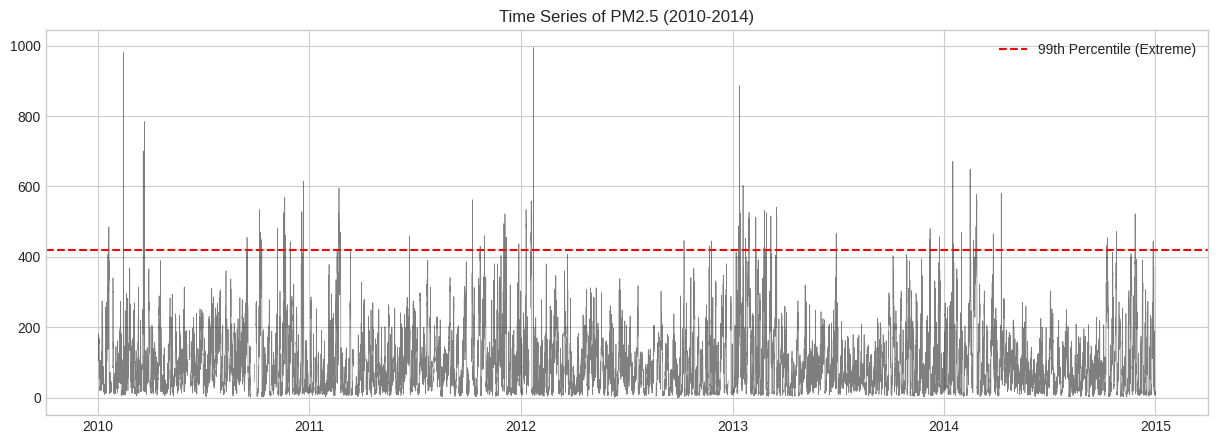

In [10]:
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Time Series & Extreme Events
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['pm2.5_clean'], color='black', alpha=0.5, linewidth=0.5)
plt.axhline(df['pm2.5_clean'].quantile(0.99), color='red', linestyle='--', label='99th Percentile (Extreme)')
plt.title('Time Series of PM2.5 (2010-2014)')
plt.legend()
plt.savefig('EDA_1_TimeSeries.png', bbox_inches='tight')
plt.show()









##5.2. Tính mùa vụ (Monthly).

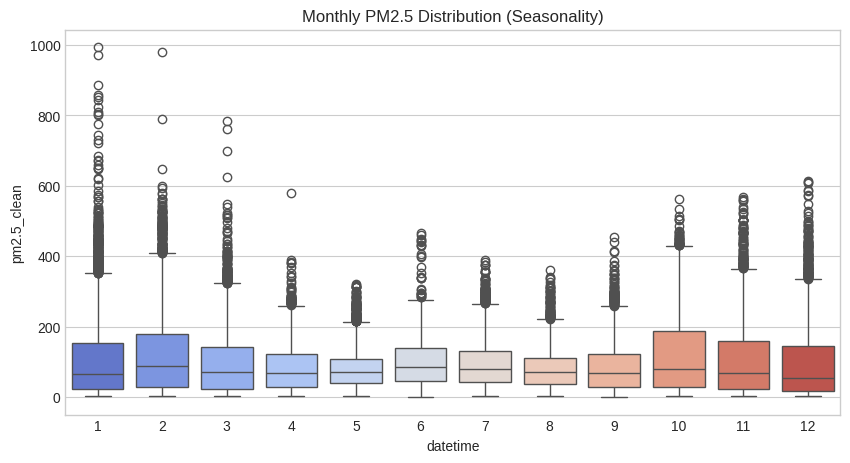

In [11]:

# 2. Monthly / Seasonal
plt.figure(figsize=(10, 5))
sns.boxplot(x=df.index.month, y=df['pm2.5_clean'], palette='coolwarm')
plt.title('Monthly PM2.5 Distribution (Seasonality)')
plt.savefig('EDA_2_Monthly.png', bbox_inches='tight')
plt.show()

##5.3. Tính nhật triều trong ngày (Hourly).

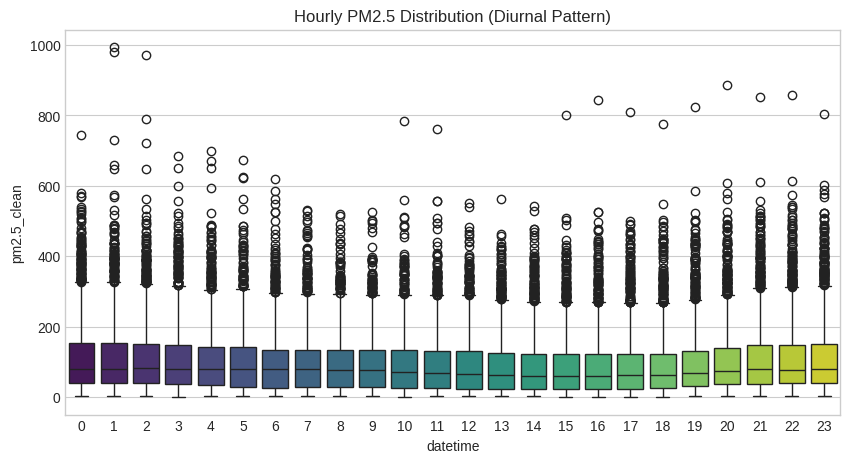

In [12]:

# 3. Hourly (Diurnal Pattern)
plt.figure(figsize=(10, 5))
sns.boxplot(x=df.index.hour, y=df['pm2.5_clean'], palette='viridis')
plt.title('Hourly PM2.5 Distribution (Diurnal Pattern)')
plt.savefig('EDA_3_Hourly.png', bbox_inches='tight')
plt.show()

##5.4. Ma trận tương quan (Correlation).

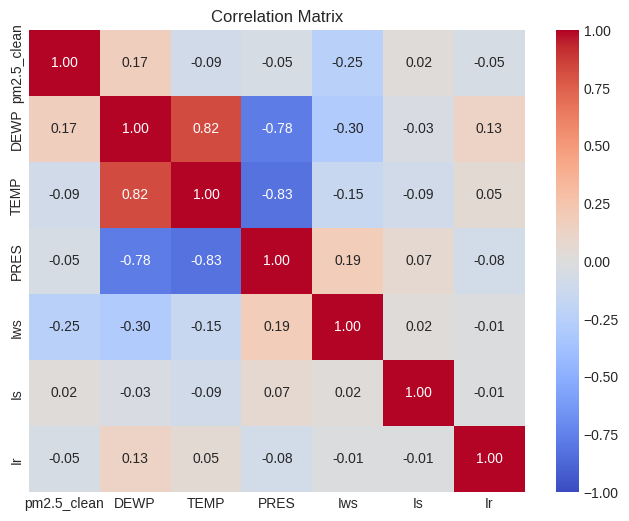

In [13]:
# 4. Correlation Matrix
plt.figure(figsize=(8, 6))
corr = df[['pm2.5_clean', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.savefig('EDA_4_Correlation.png', bbox_inches='tight')
plt.show()

##5.5. Quan hệ giữa nhiệt độ, tốc độ gió và  𝑃𝑀2.5 .Hàm tự tương quan ACF (72 Lags).

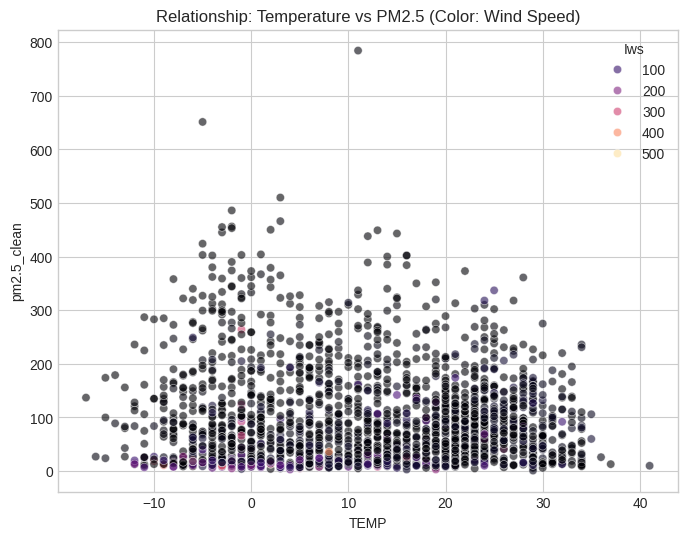

In [14]:
# 5. Weather Relationship (Temp vs PM2.5 hue Wind)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='TEMP', y='pm2.5_clean', hue='Iws', data=df.sample(2000, random_state=42), palette='magma', alpha=0.6)
plt.title('Relationship: Temperature vs PM2.5 (Color: Wind Speed)')
plt.savefig('EDA_5_Weather_Relation.png', bbox_inches='tight')
plt.show()

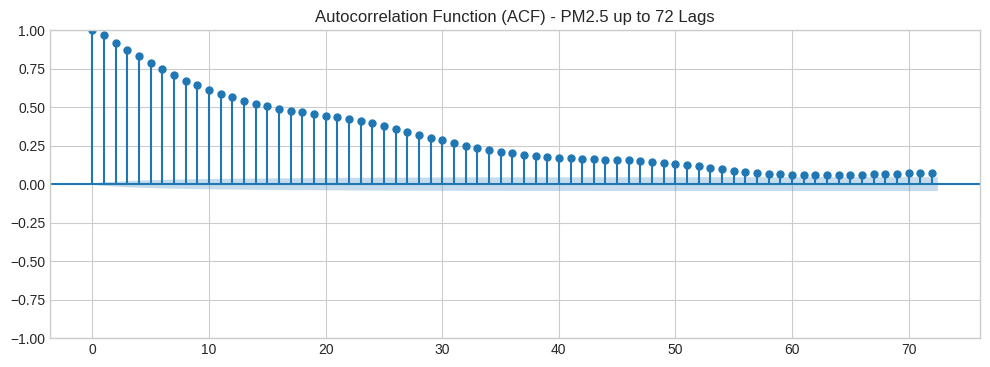

In [15]:

# 6. ACF Plot
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['pm2.5_clean'].dropna(), lags=72, ax=ax, title='Autocorrelation Function (ACF) - PM2.5 up to 72 Lags')
plt.savefig('EDA_6_ACF.png', bbox_inches='tight')
plt.show()